# 04 — National Network Analysis
## Mapping Market Competition in Portuguese Public Procurement

**Research Question:** Which companies have a dominant position within specific municipalities?

**This notebook covers:**
1. Network Construction
2. Global Network Properties
3. Degree & Strength Distributions
4. Top Companies by In-Degree and Volume
5. Geographic Dispersion of Dominant Firms
6. CPV Sector Dominance
7. Random Reference Comparison

## 1. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from community import community_louvain  # pip install python-louvain
import powerlaw  # pip install powerlaw
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# Load preprocessed data
data = pd.read_csv('../data/preprocessed_data.csv')

# Convert date columns
date_cols = ['dataDecisaoAdjudicacao', 'dataCelebracaoContrato', 'dataPublicacao', 'dataFechoContrato']
for col in date_cols:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors='coerce')

print(f"Dataset shape: {data.shape}")
print(f"Contracts: {len(data):,}")
print(f"Unique contracting authorities: {data['adjudicante_clean'].nunique():,}")
print(f"Unique companies: {data['adjudicatarios_clean'].nunique():,}")
print(f"Municipalities (cities): {data['city'].nunique()}")
print(f"\nDate range: {data['dataCelebracaoContrato'].min()} to {data['dataCelebracaoContrato'].max()}")
print(f"\nSample:")
data.head(3)

Dataset shape: (690, 22)
Contracts: 690
Unique contracting authorities: 129
Unique companies: 436
Municipalities (cities): 14

Date range: 2025-01-01 00:00:00 to 2026-02-09 00:00:00

Sample:


,idcontrato,tipoContrato,tipoFimContrato,CPV,adjudicante,adjudicatarios,concorrentes,precoBaseProcedimento,precoContratual,PrecoTotalEfetivo,...,dataPublicacao,dataFechoContrato,nr_concorrentes,contribuinte_adjudicante,contribuinte_adjudicatarios,city,cpv_prefix,agg_cpv,adjudicante_clean,adjudicatarios_clean
0,11132143,Aquisição de bens móveis,"O cumprimento, a impossibilidade definitiva e ...",44613800-8 - Contentores para resíduos,Município de Alenquer,Sopinal - Indústria de Equipamentos e Contento...,"500276218-SOPINAL, L.da | 500231206-Resopre - ...",39714.70,26308.50,26308.50,...,2025-01-06,2025-09-23,3,501305734,500276218.0,Alenquer,44,Materiais de construção,municipio de alenquer,sopinal industria de equipamentos e contentores
1,11133293,Aquisição de serviços,"O cumprimento, a impossibilidade definitiva e ...",63510000-7 - Serviços de agências de viagens e...,"Instituto da Mobilidade e dos Transportes, IP","DOT Viagens e Turismo, Lda.","500886113-Raso - Viagens e Turismo, S.A. | 506...",67180.00,67180.00,65980.96,...,2025-01-06,2026-01-27,5,508195446,514862645.0,Lisboa,63,Serviços auxiliares de transporte,instituto da mobilidade e dos transportes ip,dot viagens e turismo
2,11135590,Aquisição de bens móveis,"O cumprimento, a impossibilidade definitiva e ...",30210000-4 - Máquinas de processamento de dado...,"Edurumos, Educação, L.da","MEO - Serviços de Comunicações e Multimédia, S...",504615947-Meo - Serviços de Comunicações e Mul...,404027.62,20850.02,20333.92,...,2025-01-07,2025-12-19,6,504682687,504615947.0,Lisboa,30,Equipamento de escritório e informática,edurumos educacao l da,meo servicos de comunicacoes e multimedia s ai...


## 2. Network Construction

We build a **directed, weighted** network:
- **Nodes**: Public entities (adjudicante) and Companies (adjudicatarios)
- **Edges**: Contractual relationship (authority → company)
- **Weight**: Total contract value (€) per (authority, company) pair

In [5]:
def build_network(df):
    """Build directed weighted network from preprocessed contract data."""
    G = nx.DiGraph()

    # Aggregate by (source, target) pair
    edge_data = df.groupby(['adjudicante_clean', 'adjudicatarios_clean']).agg(
        total_value=('precoContratual', 'sum'),
        num_contracts=('idcontrato', 'count'),
        avg_value=('precoContratual', 'mean'),
        cities=('city', lambda x: list(x.unique())),
        cpv_categories=('agg_cpv', lambda x: list(x.unique())),
        cpv_prefixes=('cpv_prefix', lambda x: list(x.unique())),
        first_contract=('dataCelebracaoContrato', 'min'),
        last_contract=('dataCelebracaoContrato', 'max')
    ).reset_index()

    # Add nodes with type attribute
    all_adjudicantes = set(df['adjudicante_clean'].unique())
    all_adjudicatarios = set(df['adjudicatarios_clean'].unique())
    both = all_adjudicantes & all_adjudicatarios

    for node in all_adjudicantes - both:
        G.add_node(node, node_type='adjudicante')
    for node in all_adjudicatarios - both:
        G.add_node(node, node_type='adjudicatario')
    for node in both:
        G.add_node(node, node_type='both')

    # Add edges
    for _, row in edge_data.iterrows():
        G.add_edge(
            row['adjudicante_clean'],
            row['adjudicatarios_clean'],
            weight=row['total_value'],
            num_contracts=row['num_contracts'],
            avg_value=row['avg_value'],
            cities=row['cities'],
            cpv_categories=row['cpv_categories'],
            first_contract=row['first_contract'],
            last_contract=row['last_contract']
        )

    return G

# Build the full national network
G = build_network(data)

print(f"Network built successfully!")
print(f"Nodes (N): {G.number_of_nodes():,}")
print(f"Edges (L): {G.number_of_edges():,}")
print(f"\nNode types:")
node_types = pd.Series(nx.get_node_attributes(G, 'node_type'))
print(node_types.value_counts().to_string())

Network built successfully!
Nodes (N): 564
Edges (L): 566

Node types:
adjudicatario    435
adjudicante      128
both               1


## 3. Global Network Properties

Measurements required: N, L, density, average path length, clustering coefficient

In [6]:
# Basic properties
N = G.number_of_nodes()
L = G.number_of_edges()
density = nx.density(G)

# Average degree
avg_in_degree = np.mean([d for _, d in G.in_degree()])
avg_out_degree = np.mean([d for _, d in G.out_degree()])
avg_degree = (avg_in_degree + avg_out_degree) / 2

# Weighted degree (strength)
avg_strength_in = np.mean([d for _, d in G.in_degree(weight='weight')])
avg_strength_out = np.mean([d for _, d in G.out_degree(weight='weight')])

# Connected components (on undirected version)
G_undirected = G.to_undirected()
components = list(nx.connected_components(G_undirected))
n_components = len(components)
largest_cc = max(components, key=len)
largest_cc_size = len(largest_cc)
largest_cc_pct = largest_cc_size / N * 100

print("="*60)
print("GLOBAL NETWORK PROPERTIES")
print("="*60)
print(f"Nodes (N):                    {N:,}")
print(f"Edges (L):                    {L:,}")
print(f"Density:                      {density:.6f}")
print(f"Avg In-Degree:                {avg_in_degree:.2f}")
print(f"Avg Out-Degree:               {avg_out_degree:.2f}")
print(f"Avg Weighted In-Degree:       {avg_strength_in:,.2f} €")
print(f"Avg Weighted Out-Degree:      {avg_strength_out:,.2f} €")
print(f"Connected Components:         {n_components}")
print(f"Largest Component:            {largest_cc_size:,} nodes ({largest_cc_pct:.1f}%)")

GLOBAL NETWORK PROPERTIES
Nodes (N):                    564
Edges (L):                    566
Density:                      0.001782
Avg In-Degree:                1.00
Avg Out-Degree:               1.00
Avg Weighted In-Degree:       128,185.12 €
Avg Weighted Out-Degree:      128,185.12 €
Connected Components:         42
Largest Component:            414 nodes (73.4%)


In [7]:
# Average path length and clustering (computed on largest connected component)
# These can be slow on large graphs, so we compute on the largest CC

G_lcc = G_undirected.subgraph(largest_cc).copy()

print(f"Computing average path length on largest CC ({len(G_lcc):,} nodes)...")
print("(This may take a while for large networks — sampling if N > 5000)")

if len(G_lcc) > 5000:
    # Sample-based estimation for large networks
    sample_size = min(1000, len(G_lcc))
    sample_nodes = np.random.choice(list(G_lcc.nodes()), size=sample_size, replace=False)
    path_lengths = []
    for node in sample_nodes:
        spl = nx.single_source_shortest_path_length(G_lcc, node)
        path_lengths.extend(spl.values())
    avg_path_length = np.mean(path_lengths)
    print(f"Avg Path Length (sampled, n={sample_size}): {avg_path_length:.4f}")
else:
    avg_path_length = nx.average_shortest_path_length(G_lcc)
    print(f"Avg Path Length (exact): {avg_path_length:.4f}")

# Clustering coefficient (undirected)
print("\nComputing clustering coefficient...")
avg_clustering = nx.average_clustering(G_undirected)
print(f"Average Clustering Coefficient: {avg_clustering:.6f}")

# Transitivity (global clustering)
transitivity = nx.transitivity(G_undirected)
print(f"Transitivity (global):          {transitivity:.6f}")

Computing average path length on largest CC (414 nodes)...
(This may take a while for large networks — sampling if N > 5000)
Avg Path Length (exact): 6.0062

Computing clustering coefficient...
Average Clustering Coefficient: 0.000000
Transitivity (global):          0.000000


In [8]:
# Summary table for presentation
properties_table = pd.DataFrame({
    'Metric': ['Nodes (N)', 'Edges (L)', 'Density', 'Avg Degree ⟨k⟩', 
               'Avg Strength ⟨s⟩ (€)', 'Avg Path Length ⟨d⟩', 
               'Clustering Coeff. C', 'Transitivity',
               'Connected Components', 'Largest CC (%)'],
    'Value': [f"{N:,}", f"{L:,}", f"{density:.6f}", f"{avg_degree:.2f}",
              f"{avg_strength_in:,.0f}", f"{avg_path_length:.3f}",
              f"{avg_clustering:.6f}", f"{transitivity:.6f}",
              f"{n_components}", f"{largest_cc_pct:.1f}%"]
})
print(properties_table.to_string(index=False))

              Metric    Value
           Nodes (N)      564
           Edges (L)      566
             Density 0.001782
      Avg Degree ⟨k⟩     1.00
Avg Strength ⟨s⟩ (€)  128,185
 Avg Path Length ⟨d⟩    6.006
 Clustering Coeff. C 0.000000
        Transitivity 0.000000
Connected Components       42
      Largest CC (%)    73.4%


## 4. Degree & Strength Distributions

We analyze:
- **Degree distribution P(k)**: How many connections each node has
- **Strength distribution P(s)**: Total contract value flowing through each node

For the RQ on dominance, heavy-tailed distributions suggest a few dominant players.

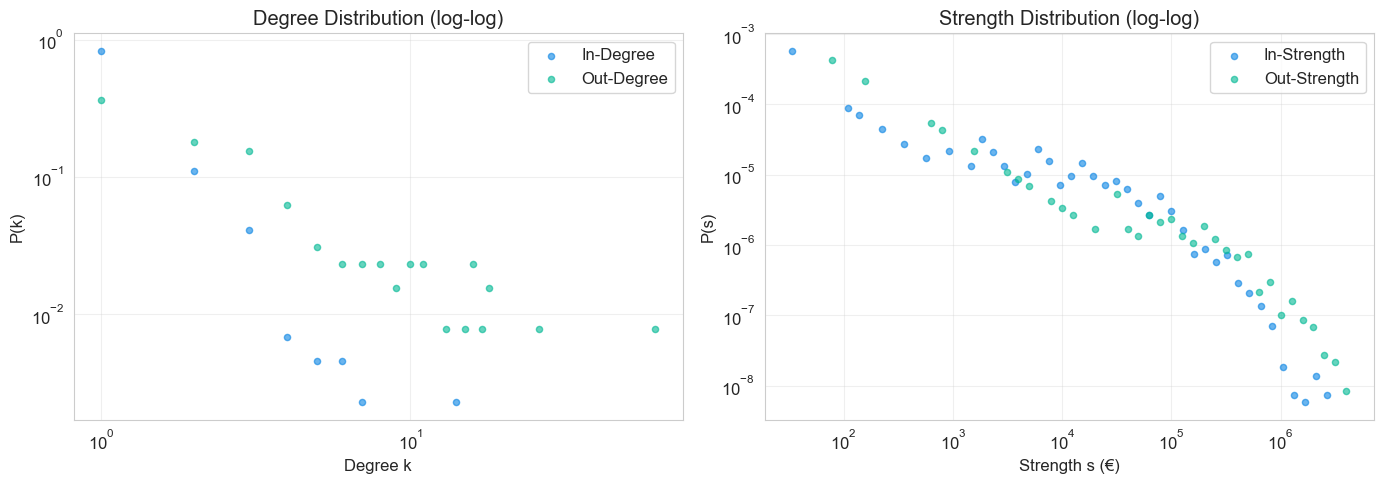


In-Degree: min=1, max=14, median=1
In-Strength: min=30€, max=2,999,800€, median=60,051€


In [10]:
# In-degree distribution (number of contracts received by companies)
in_degrees = [d for _, d in G.in_degree() if d > 0]
out_degrees = [d for _, d in G.out_degree() if d > 0]

# Strength (weighted degree) distribution
in_strengths = [d for _, d in G.in_degree(weight='weight') if d > 0]
out_strengths = [d for _, d in G.out_degree(weight='weight') if d > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Degree Distribution (log-log) ---
ax = axes[0]
# In-degree histogram
degree_counts = Counter(in_degrees)
degrees = sorted(degree_counts.keys())
probs = [degree_counts[d] / len(in_degrees) for d in degrees]
ax.scatter(degrees, probs, alpha=0.6, s=20, color='#0984e3', label='In-Degree')

# Out-degree histogram
degree_counts_out = Counter(out_degrees)
degrees_out = sorted(degree_counts_out.keys())
probs_out = [degree_counts_out[d] / len(out_degrees) for d in degrees_out]
ax.scatter(degrees_out, probs_out, alpha=0.6, s=20, color='#00b894', label='Out-Degree')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree k')
ax.set_ylabel('P(k)')
ax.set_title('Degree Distribution (log-log)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Strength Distribution (log-log) ---
ax = axes[1]
# Use log-binning for continuous-valued strengths
bins = np.logspace(np.log10(min(in_strengths)), np.log10(max(in_strengths)), 50)
hist, bin_edges = np.histogram(in_strengths, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
mask = hist > 0
ax.scatter(bin_centers[mask], hist[mask], alpha=0.6, s=20, color='#0984e3', label='In-Strength')

bins_out = np.logspace(np.log10(min(out_strengths)), np.log10(max(out_strengths)), 50)
hist_out, bin_edges_out = np.histogram(out_strengths, bins=bins_out, density=True)
bin_centers_out = (bin_edges_out[:-1] + bin_edges_out[1:]) / 2
mask_out = hist_out > 0
ax.scatter(bin_centers_out[mask_out], hist_out[mask_out], alpha=0.6, s=20, color='#00b894', label='Out-Strength')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Strength s (€)')
ax.set_ylabel('P(s)')
ax.set_title('Strength Distribution (log-log)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nIn-Degree: min={min(in_degrees)}, max={max(in_degrees)}, median={np.median(in_degrees):.0f}")
print(f"In-Strength: min={min(in_strengths):.0f}€, max={max(in_strengths):,.0f}€, median={np.median(in_strengths):,.0f}€")

In [11]:
# Power-law fit for degree distribution
print("="*60)
print("POWER-LAW ANALYSIS")
print("="*60)

# Fit in-degree to power-law
fit_in = powerlaw.Fit(in_degrees, discrete=True, verbose=False)
print(f"\nIn-Degree Distribution:")
print(f"  Power-law exponent (alpha): {fit_in.alpha:.3f}")
print(f"  x_min: {fit_in.xmin}")
print(f"  KS distance: {fit_in.D:.4f}")

# Compare power-law vs exponential vs lognormal
R_exp, p_exp = fit_in.distribution_compare('power_law', 'exponential')
R_ln, p_ln = fit_in.distribution_compare('power_law', 'lognormal')
print(f"  vs Exponential: R={R_exp:.3f}, p={p_exp:.4f} {'(power-law better)' if R_exp > 0 else '(exponential better)'}")
print(f"  vs Lognormal:   R={R_ln:.3f}, p={p_ln:.4f} {'(power-law better)' if R_ln > 0 else '(lognormal better)'}")

# Fit in-strength
fit_s = powerlaw.Fit(in_strengths, discrete=False, verbose=False)
print(f"\nIn-Strength Distribution:")
print(f"  Power-law exponent (alpha): {fit_s.alpha:.3f}")
print(f"  x_min: {fit_s.xmin:,.0f}")

# Interpretation
print("\n" + "="*60)
print("INTERPRETATION:")
if fit_in.alpha < 3:
    print("  → Heavy-tailed degree distribution (alpha < 3)")
    print("  → A few companies receive a disproportionate number of contracts")
    print("  → This indicates MARKET CONCENTRATION")
else:
    print("  → Relatively homogeneous degree distribution")
    print("  → Contracts are more evenly distributed")

POWER-LAW ANALYSIS

In-Degree Distribution:
  Power-law exponent (alpha): 3.000
  x_min: 1.0
  KS distance: 0.0127
  vs Exponential: R=18.997, p=0.1383 (power-law better)
  vs Lognormal:   R=-1.048, p=0.4233 (lognormal better)

In-Strength Distribution:
  Power-law exponent (alpha): 2.550
  x_min: 274,250

INTERPRETATION:
  → Heavy-tailed degree distribution (alpha < 3)
  → A few companies receive a disproportionate number of contracts
  → This indicates MARKET CONCENTRATION


## 5. National Dominance Analysis

### 5.1 Top Companies by Number of Contracts (In-Degree)

In [12]:
# Companies = nodes with in-degree > 0 (they receive contracts)
company_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') in ['adjudicatario', 'both']]

# In-degree ranking (number of distinct contracting authorities)
in_degree_ranking = sorted(
    [(node, G.in_degree(node)) for node in company_nodes],
    key=lambda x: x[1], reverse=True
)

# Top 20 by contracts
top20_degree = pd.DataFrame(in_degree_ranking[:20], columns=['Company', 'In-Degree (# Authorities)'])
top20_degree['Rank'] = range(1, 21)
top20_degree = top20_degree[['Rank', 'Company', 'In-Degree (# Authorities)']]

print("="*60)
print("TOP 20 COMPANIES BY IN-DEGREE (Number of Contracting Authorities)")
print("="*60)
print(top20_degree.to_string(index=False))

TOP 20 COMPANIES BY IN-DEGREE (Number of Contracting Authorities)
 Rank                                            Company  In-Degree (# Authorities)
    1                              claranet ii solutions                         14
    2                       exitus solucoes tecnologicas                          7
    3                 inetum espana sucursal em portugal                          6
    4                ohmtecnica representacoes de marcas                          6
    5                                         papelprint                          5
    6                   timestamp sistemas de informacao                          5
    7                                  claranet portugal                          4
    8                                   planeta vertical                          4
    9                                              base2                          4
   10 edni empresa distribiudora de material informatico                          3
   11     

### 5.2 Top Companies by Volume (Weighted In-Degree / Strength)

In [13]:
# Strength ranking (total contract value received)
strength_ranking = sorted(
    [(node, G.in_degree(node, weight='weight')) for node in company_nodes],
    key=lambda x: x[1], reverse=True
)

top20_strength = pd.DataFrame(strength_ranking[:20], columns=['Company', 'Total Volume (€)'])
top20_strength['Rank'] = range(1, 21)
top20_strength['Total Volume (€)'] = top20_strength['Total Volume (€)'].apply(lambda x: f"{x:,.2f}")
top20_strength = top20_strength[['Rank', 'Company', 'Total Volume (€)']]

print("="*60)
print("TOP 20 COMPANIES BY STRENGTH (Total Contract Value Received)")
print("="*60)
print(top20_strength.to_string(index=False))

TOP 20 COMPANIES BY STRENGTH (Total Contract Value Received)
 Rank                                   Company Total Volume (€)
    1                                   paldata     2,999,800.00
    2                     claranet ii solutions     2,867,339.00
    3        inetum espana sucursal em portugal     2,734,017.21
    4                          nos comunicacoes     2,210,994.96
    5                          warpcom services     2,201,028.62
    6 meo servicos de comunicacoes e multimedia     2,191,600.14
    7                           hccm consulting     1,566,520.75
    8   vodafone portugal comunicacoes pessoais     1,172,257.83
    9              fujitsu technology solutions     1,107,248.27
   10            reload consultoria informatica       964,522.35
   11                 crayon software licensing       850,306.60
   12         xix construcao projectos e gestao       837,392.14
   13          vortice equipamentos cientificos       798,900.00
   14            linkcom sist

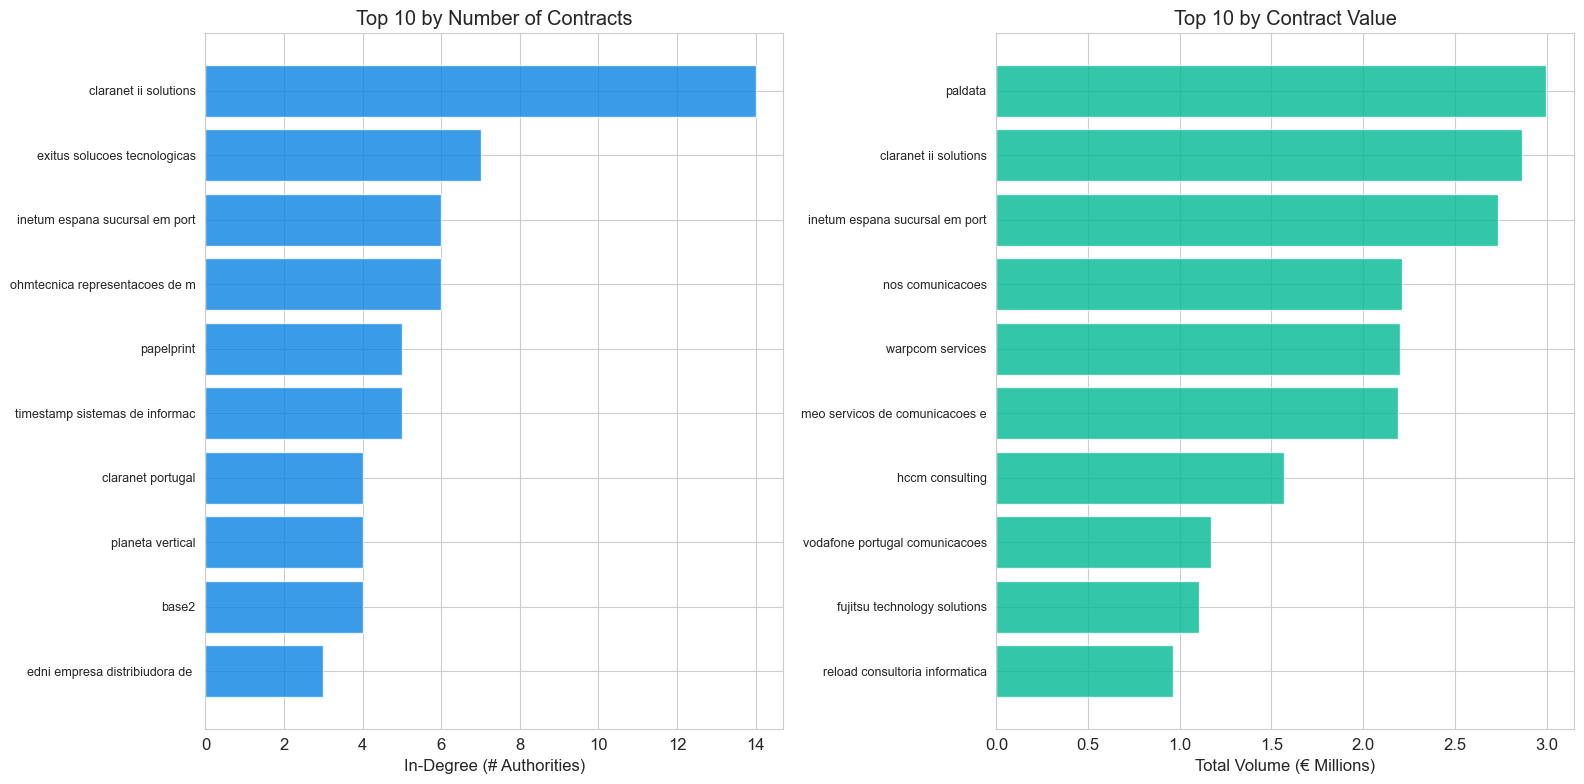


Overlap in Top 20 (degree ∩ volume): 6 companies
→ Different companies dominate contracts vs value


In [14]:
# Combined visualization: Top 10 by degree vs volume
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 10 by in-degree
top10_d = in_degree_ranking[:10]
names_d = [x[0][:30] for x in top10_d]  # truncate names
vals_d = [x[1] for x in top10_d]
axes[0].barh(range(10), vals_d, color='#0984e3', alpha=0.8)
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(names_d, fontsize=9)
axes[0].set_xlabel('In-Degree (# Authorities)')
axes[0].set_title('Top 10 by Number of Contracts')
axes[0].invert_yaxis()

# Top 10 by strength
top10_s = strength_ranking[:10]
names_s = [x[0][:30] for x in top10_s]
vals_s = [x[1] / 1e6 for x in top10_s]  # Convert to millions
axes[1].barh(range(10), vals_s, color='#00b894', alpha=0.8)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(names_s, fontsize=9)
axes[1].set_xlabel('Total Volume (€ Millions)')
axes[1].set_title('Top 10 by Contract Value')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../figures/top10_national.png', dpi=150, bbox_inches='tight')
plt.show()

# Check overlap between top degree and top volume companies
top20_degree_set = set([x[0] for x in in_degree_ranking[:20]])
top20_strength_set = set([x[0] for x in strength_ranking[:20]])
overlap = top20_degree_set & top20_strength_set
print(f"\nOverlap in Top 20 (degree ∩ volume): {len(overlap)} companies")
print(f"→ {'Same players dominate both metrics' if len(overlap) > 10 else 'Different companies dominate contracts vs value'}")

### 5.3 Geographic Dispersion of Dominant Companies

How many municipalities does each top company operate in?

In [15]:
# For each company, count unique municipalities they have contracts in
company_cities = data.groupby('adjudicatarios_clean')['city'].nunique().reset_index()
company_cities.columns = ['Company', 'Num_Municipalities']
company_cities = company_cities.sort_values('Num_Municipalities', ascending=False)

total_municipalities = data['city'].nunique()
print(f"Total municipalities in dataset: {total_municipalities}")
print(f"\nTop 20 companies by geographic reach:")
print("="*60)

top20_geo = company_cities.head(20).copy()
top20_geo['Reach (%)'] = (top20_geo['Num_Municipalities'] / total_municipalities * 100).round(1)
top20_geo['Rank'] = range(1, 21)
top20_geo = top20_geo[['Rank', 'Company', 'Num_Municipalities', 'Reach (%)']]
print(top20_geo.to_string(index=False))

Total municipalities in dataset: 14

Top 20 companies by geographic reach:
 Rank                                              Company  Num_Municipalities  Reach (%)
    1                                    contenur portugal                   3       21.4
    2                                     renault portugal                   3       21.4
    3                                    claranet portugal                   2       14.3
    4                     carclasse comercio de automoveis                   2       14.3
    5            idw consultoria em servicos de informacao                   2       14.3
    6                beltrao coelho sistemas de escritorio                   2       14.3
    7                    janz contagem e gestao de fluidos                   2       14.3
    8                                     knowledge inside                   2       14.3
    9                                      eurest portugal                   2       14.3
   10                    

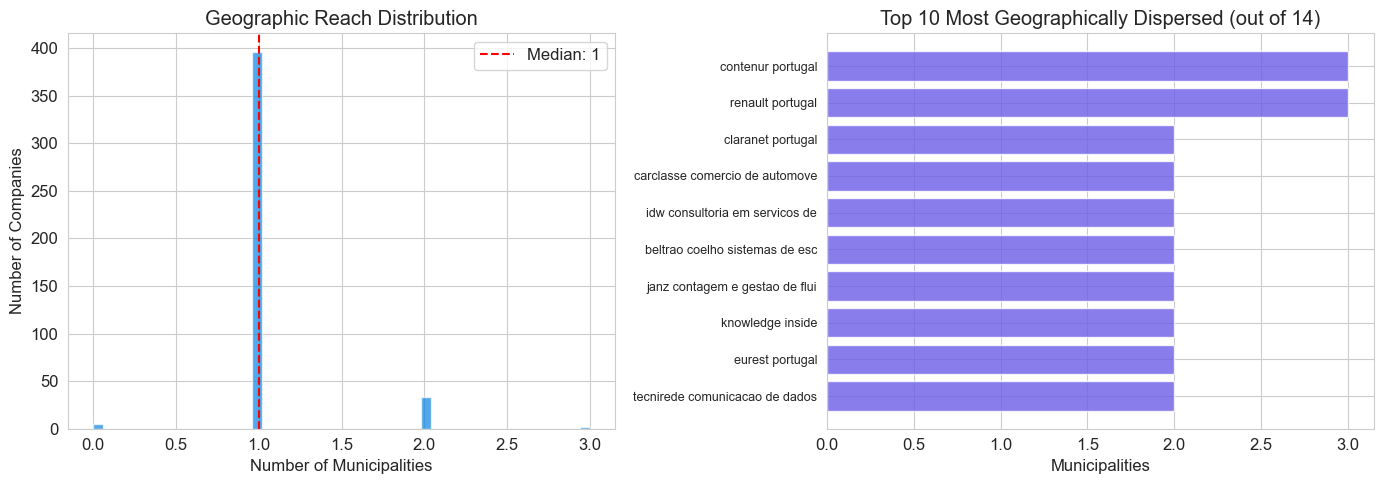


Companies active in 50%+ municipalities: 0


In [16]:
# Geographic concentration: distribution of companies by number of municipalities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of geographic reach
ax = axes[0]
ax.hist(company_cities['Num_Municipalities'], bins=50, color='#0984e3', alpha=0.7, edgecolor='white')
ax.set_xlabel('Number of Municipalities')
ax.set_ylabel('Number of Companies')
ax.set_title('Geographic Reach Distribution')
ax.axvline(company_cities['Num_Municipalities'].median(), color='red', linestyle='--', label=f"Median: {company_cities['Num_Municipalities'].median():.0f}")
ax.legend()

# Top 10 geographic reach
ax = axes[1]
top10_geo = company_cities.head(10)
ax.barh(range(10), top10_geo['Num_Municipalities'], color='#6c5ce7', alpha=0.8)
ax.set_yticks(range(10))
ax.set_yticklabels([name[:30] for name in top10_geo['Company']], fontsize=9)
ax.set_xlabel('Municipalities')
ax.set_title(f'Top 10 Most Geographically Dispersed (out of {total_municipalities})')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../figures/geographic_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

# Companies in 50%+ municipalities
threshold = total_municipalities * 0.5
widespread = company_cities[company_cities['Num_Municipalities'] >= threshold]
print(f"\nCompanies active in 50%+ municipalities: {len(widespread)}")
if len(widespread) > 0:
    print(widespread[['Company', 'Num_Municipalities']].to_string(index=False))

### 5.4 Sector Dominance by CPV Category

Which companies dominate which procurement sectors (CPV 2-digit divisions)?

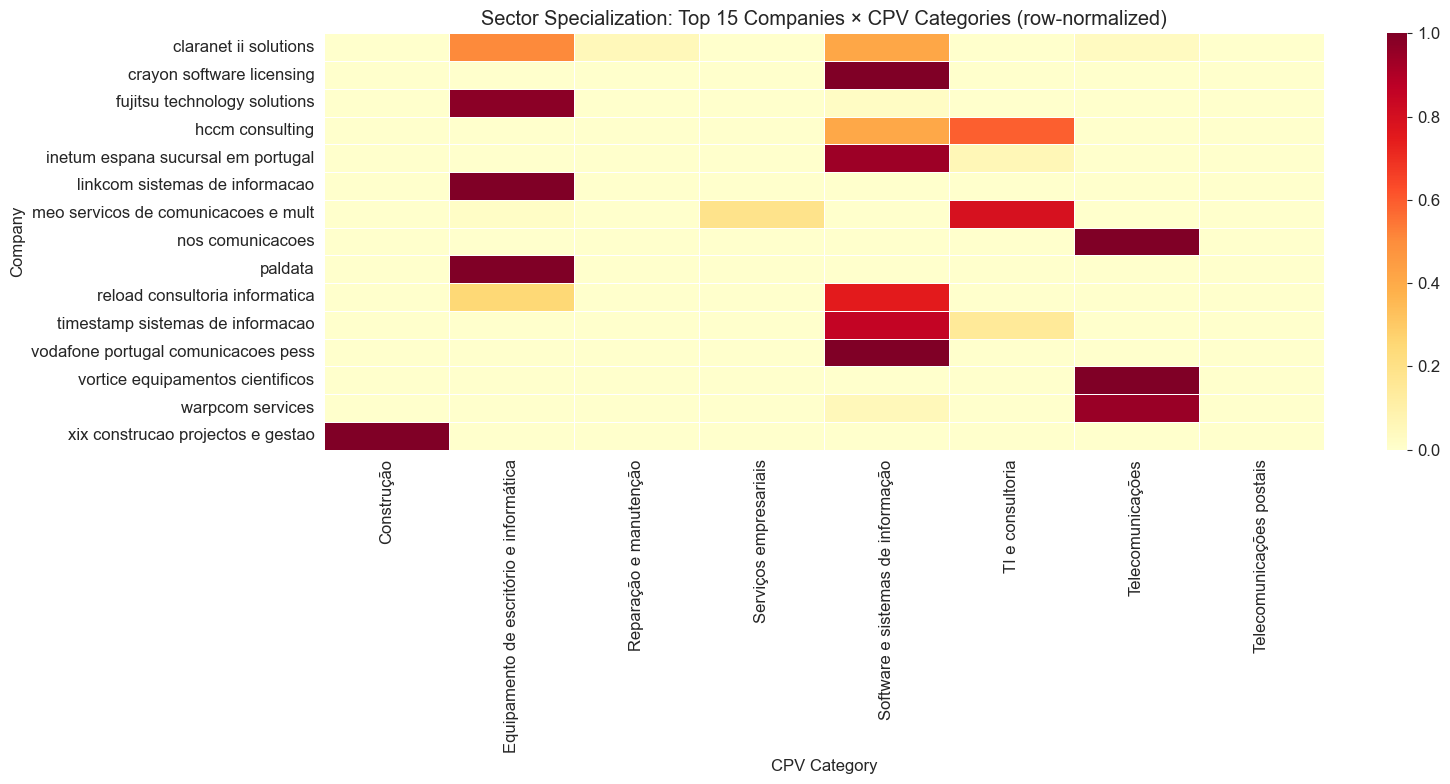


Average CPV categories per company: 1.1
Max CPV categories (most generalist): 4
Companies in only 1 CPV (specialists): 387 (88.8%)


In [17]:
# Top companies per CPV category
cpv_dominance = data.groupby(['agg_cpv', 'adjudicatarios_clean']).agg(
    total_value=('precoContratual', 'sum'),
    num_contracts=('idcontrato', 'count')
).reset_index()

# For each CPV, find top 3 companies by value
top_per_cpv = cpv_dominance.sort_values(['agg_cpv', 'total_value'], ascending=[True, False])
top_per_cpv = top_per_cpv.groupby('agg_cpv').head(3)

# Pivot for heatmap: top companies across sectors
top_companies_overall = [x[0] for x in strength_ranking[:15]]
cpv_matrix = data[data['adjudicatarios_clean'].isin(top_companies_overall)].groupby(
    ['adjudicatarios_clean', 'agg_cpv']
)['precoContratual'].sum().reset_index()
cpv_pivot = cpv_matrix.pivot_table(index='adjudicatarios_clean', columns='agg_cpv', values='precoContratual', fill_value=0)

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 8))
# Normalize by row (company) for better visualization
cpv_normalized = cpv_pivot.div(cpv_pivot.sum(axis=1), axis=0)
sns.heatmap(cpv_normalized, cmap='YlOrRd', ax=ax, linewidths=0.5,
            yticklabels=[name[:35] for name in cpv_normalized.index])
ax.set_xlabel('CPV Category')
ax.set_ylabel('Company')
ax.set_title('Sector Specialization: Top 15 Companies × CPV Categories (row-normalized)')
plt.tight_layout()
plt.savefig('../figures/cpv_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary: Specialist vs Generalist
company_cpv_count = data.groupby('adjudicatarios_clean')['agg_cpv'].nunique()
print(f"\nAverage CPV categories per company: {company_cpv_count.mean():.1f}")
print(f"Max CPV categories (most generalist): {company_cpv_count.max()}")
print(f"Companies in only 1 CPV (specialists): {(company_cpv_count == 1).sum()} ({(company_cpv_count == 1).mean()*100:.1f}%)")

## 6. Random Reference Comparison

We compare our network to an Erdős-Rényi (ER) random graph with the same N and ⟨k⟩ to understand what properties arise from the network structure vs. what would appear by chance.

In [18]:
# Generate ER random reference with same N and density
np.random.seed(42)
G_er = nx.erdos_renyi_graph(N, density, directed=True)

# Compute properties of random reference
er_clustering = nx.average_clustering(G_er.to_undirected())
er_components = nx.number_connected_components(G_er.to_undirected())
er_in_degrees = [d for _, d in G_er.in_degree() if d > 0]

# For path length, sample if large
G_er_und = G_er.to_undirected()
er_largest_cc = max(nx.connected_components(G_er_und), key=len)
G_er_lcc = G_er_und.subgraph(er_largest_cc)

if len(G_er_lcc) > 5000:
    sample_nodes = np.random.choice(list(G_er_lcc.nodes()), size=min(500, len(G_er_lcc)), replace=False)
    er_paths = []
    for node in sample_nodes:
        spl = nx.single_source_shortest_path_length(G_er_lcc, node)
        er_paths.extend(spl.values())
    er_avg_path = np.mean(er_paths)
else:
    er_avg_path = nx.average_shortest_path_length(G_er_lcc)

# Comparison table
print("="*60)
print("COMPARISON: REAL NETWORK vs RANDOM REFERENCE (ER model)")
print("="*60)
comparison = pd.DataFrame({
    'Metric': ['Avg Clustering Coeff', 'Avg Path Length', 'Max In-Degree', 
               'Degree Std Dev', 'Components'],
    'Real Network': [f"{avg_clustering:.6f}", f"{avg_path_length:.3f}", 
                     f"{max(in_degrees)}", f"{np.std(in_degrees):.2f}",
                     f"{n_components}"],
    'ER Random': [f"{er_clustering:.6f}", f"{er_avg_path:.3f}",
                  f"{max(er_in_degrees) if er_in_degrees else 0}", 
                  f"{np.std(er_in_degrees):.2f}" if er_in_degrees else "0",
                  f"{er_components}"],
    'Interpretation': [
        'Higher → local clustering/groups' if avg_clustering > er_clustering else 'Similar to random',
        'Small-world?' if avg_path_length < er_avg_path * 1.5 else 'Longer paths than random',
        'Hub presence' if max(in_degrees) > max(er_in_degrees) * 2 else 'No extreme hubs',
        'Heterogeneous' if np.std(in_degrees) > np.std(er_in_degrees) * 2 else 'Homogeneous',
        ''
    ]
})
print(comparison.to_string(index=False))

COMPARISON: REAL NETWORK vs RANDOM REFERENCE (ER model)
              Metric Real Network ER Random    Interpretation
Avg Clustering Coeff     0.000000  0.000000 Similar to random
     Avg Path Length        6.006     7.777      Small-world?
       Max In-Degree           14         5      Hub presence
      Degree Std Dev         0.95      0.81       Homogeneous
          Components           42       111                  


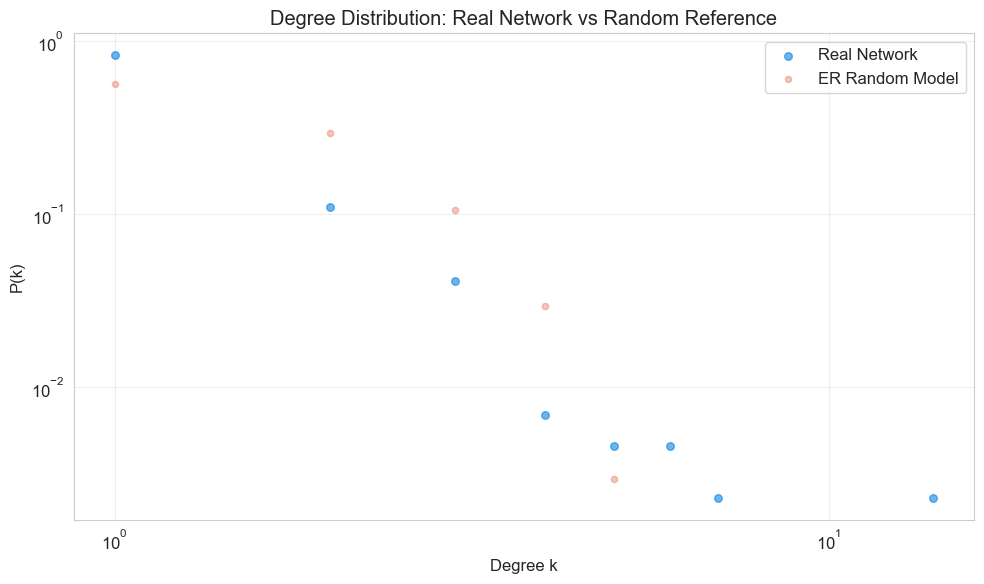


Interpretation:
→ If the real network shows a heavy tail (straight line in log-log),
  this indicates preferential attachment / market concentration.
→ ER model shows Poisson distribution (narrow peak, rapid decay).
→ The GAP between the two reveals non-random market structure.


In [19]:
# Visual comparison of degree distributions
fig, ax = plt.subplots(figsize=(10, 6))

# Real network
degree_counts_real = Counter(in_degrees)
k_real = sorted(degree_counts_real.keys())
pk_real = [degree_counts_real[k] / len(in_degrees) for k in k_real]
ax.scatter(k_real, pk_real, alpha=0.6, s=30, color='#0984e3', label='Real Network', zorder=5)

# ER reference
if er_in_degrees:
    degree_counts_er = Counter(er_in_degrees)
    k_er = sorted(degree_counts_er.keys())
    pk_er = [degree_counts_er[k] / len(er_in_degrees) for k in k_er]
    ax.scatter(k_er, pk_er, alpha=0.4, s=20, color='#e17055', label='ER Random Model', zorder=4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree k')
ax.set_ylabel('P(k)')
ax.set_title('Degree Distribution: Real Network vs Random Reference')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/degree_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("→ If the real network shows a heavy tail (straight line in log-log),")
print("  this indicates preferential attachment / market concentration.")
print("→ ER model shows Poisson distribution (narrow peak, rapid decay).")
print("→ The GAP between the two reveals non-random market structure.")

## 7. Municipality-Level Dominance Analysis

**Directly answering the RQ:** Which companies dominate within each municipality?

In [20]:
# Build per-municipality dominance table
municipality_dominance = data.groupby(['city', 'adjudicatarios_clean']).agg(
    total_value=('precoContratual', 'sum'),
    num_contracts=('idcontrato', 'count'),
    num_authorities=('adjudicante_clean', 'nunique')
).reset_index()

# Market share per municipality
municipality_totals = data.groupby('city')['precoContratual'].sum().reset_index()
municipality_totals.columns = ['city', 'city_total_value']
municipality_dominance = municipality_dominance.merge(municipality_totals, on='city')
municipality_dominance['market_share'] = municipality_dominance['total_value'] / municipality_dominance['city_total_value'] * 100

# Find the dominant company per municipality
dominant_per_city = municipality_dominance.sort_values(['city', 'market_share'], ascending=[True, False])
top1_per_city = dominant_per_city.groupby('city').first().reset_index()

print("="*60)
print("DOMINANT COMPANY PER MUNICIPALITY (by market share)")
print("="*60)
print(f"\nMunicipalities analyzed: {top1_per_city['city'].nunique()}")
print(f"Average dominance of #1 company: {top1_per_city['market_share'].mean():.1f}%")
print(f"Max dominance: {top1_per_city['market_share'].max():.1f}%")
print(f"Min dominance: {top1_per_city['market_share'].min():.1f}%")
print(f"\nTop 15 most concentrated municipalities:")
concentrated = top1_per_city.nlargest(15, 'market_share')[['city', 'adjudicatarios_clean', 'market_share', 'num_contracts']]
concentrated.columns = ['Municipality', 'Dominant Company', 'Market Share (%)', 'Contracts']
concentrated['Market Share (%)'] = concentrated['Market Share (%)'].round(1)
print(concentrated.to_string(index=False))

DOMINANT COMPANY PER MUNICIPALITY (by market share)

Municipalities analyzed: 14
Average dominance of #1 company: 34.1%
Max dominance: 72.0%
Min dominance: 5.9%

Top 15 most concentrated municipalities:
          Municipality                                              Dominant Company  Market Share (%)  Contracts
Sobral de Monte Agraço                                           construcoes pragosa              72.0          1
              Lourinhã                                            mendes &amp irmaos              63.3          2
               Cadaval                                                     jopiramos              53.0          1
         Torres Vedras        know how sociedade de ensino de languas e accao social              51.9          1
               Cascais                                         sma seguranca privada              37.2          1
              Odivelas                                             claranet portugal              36.2          1

MARKET CONCENTRATION INDEX (HHI) PER MUNICIPALITY

Highly concentrated (HHI > 2500): 7 municipalities
Moderately concentrated (1500-2500): 2
Competitive (HHI < 1500): 5


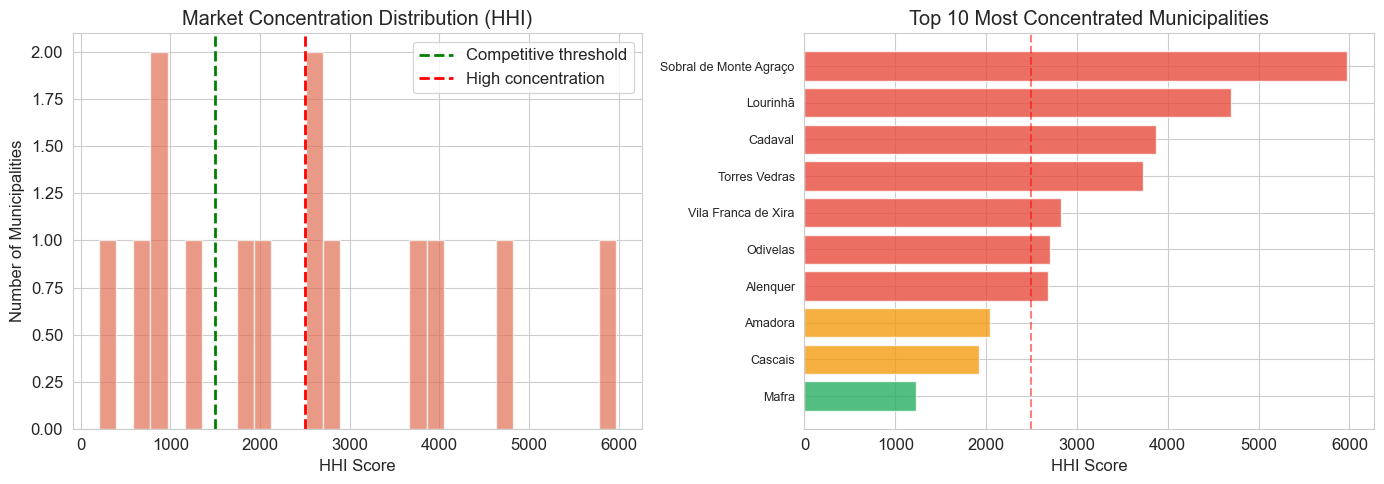

In [21]:
# Concentration index per municipality: HHI (Herfindahl-Hirschman Index)
def compute_hhi(group):
    """Compute HHI (0-10000 scale) for market concentration."""
    total = group['total_value'].sum()
    if total == 0:
        return 0
    shares = (group['total_value'] / total * 100) ** 2
    return shares.sum()

hhi_per_city = municipality_dominance.groupby('city').apply(compute_hhi).reset_index()
hhi_per_city.columns = ['city', 'HHI']
hhi_per_city = hhi_per_city.sort_values('HHI', ascending=False)

# HHI interpretation
# < 1500: competitive market
# 1500-2500: moderately concentrated
# > 2500: highly concentrated

print("="*60)
print("MARKET CONCENTRATION INDEX (HHI) PER MUNICIPALITY")
print("="*60)
print(f"\nHighly concentrated (HHI > 2500): {(hhi_per_city['HHI'] > 2500).sum()} municipalities")
print(f"Moderately concentrated (1500-2500): {((hhi_per_city['HHI'] >= 1500) & (hhi_per_city['HHI'] <= 2500)).sum()}")
print(f"Competitive (HHI < 1500): {(hhi_per_city['HHI'] < 1500).sum()}")

# Plot HHI distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(hhi_per_city['HHI'], bins=30, color='#e17055', alpha=0.7, edgecolor='white')
ax.axvline(1500, color='green', linestyle='--', linewidth=2, label='Competitive threshold')
ax.axvline(2500, color='red', linestyle='--', linewidth=2, label='High concentration')
ax.set_xlabel('HHI Score')
ax.set_ylabel('Number of Municipalities')
ax.set_title('Market Concentration Distribution (HHI)')
ax.legend()

# Top 10 most concentrated
ax = axes[1]
top10_hhi = hhi_per_city.head(10)
colors = ['#e74c3c' if h > 2500 else '#f39c12' if h > 1500 else '#27ae60' for h in top10_hhi['HHI']]
ax.barh(range(10), top10_hhi['HHI'], color=colors, alpha=0.8)
ax.set_yticks(range(10))
ax.set_yticklabels(top10_hhi['city'], fontsize=9)
ax.set_xlabel('HHI Score')
ax.set_title('Top 10 Most Concentrated Municipalities')
ax.axvline(2500, color='red', linestyle='--', alpha=0.5)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../figures/hhi_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export Network

Save the network for use in other notebooks and Gephi visualization.

In [23]:
# Save network
import os
os.makedirs('../graphs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# GEXF does not support list attributes directly; convert them before export
G_export = G.copy()

for _, _, attrs in G_export.edges(data=True):
    for key in ['cities', 'cpv_categories', 'cpv_prefixes']:
        if key in attrs and isinstance(attrs[key], (list, tuple, set, np.ndarray)):
            attrs[key] = ' | '.join(map(str, attrs[key]))

    for key in ['first_contract', 'last_contract']:
        if key in attrs:
            if pd.isna(attrs[key]):
                attrs[key] = ''
            else:
                attrs[key] = pd.to_datetime(attrs[key]).isoformat()

nx.write_gexf(G_export, '../graphs/national_network.gexf')
print("Network saved to ../graphs/national_network.gexf")

# Save key metrics for use in other notebooks
metrics = {
    'N': N, 'L': L, 'density': density,
    'avg_degree': avg_degree,
    'avg_path_length': avg_path_length,
    'avg_clustering': avg_clustering,
    'transitivity': transitivity,
    'n_components': n_components,
    'largest_cc_pct': largest_cc_pct
}
pd.Series(metrics).to_csv('../data/network_metrics.csv')
print("Metrics saved to ../data/network_metrics.csv")
print("\n✅ Notebook 04 complete!")

Network saved to ../graphs/national_network.gexf
Metrics saved to ../data/network_metrics.csv

✅ Notebook 04 complete!
